In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors

#Two new packages!
import xarray as xr
import cartopy.crs as ccrs

In [2]:
ds = xr.open_dataset('/Users/siobhankassem/Desktop/USC/Classes/Fall 2026/Python Data Science/Datasets/GEOS-CF_AirQuality_20180101_0030z.nc4')

In [3]:
ds

<xarray.Dataset> Size: 21MB
Dimensions:        (time: 1, lev: 1, lat: 721, lon: 1440)
Coordinates:
  * time           (time) datetime64[ns] 8B 2018-01-01T00:30:00
  * lev            (lev) float64 8B 72.0
  * lat            (lat) float64 6kB -90.0 -89.75 -89.5 ... 89.5 89.75 90.0
  * lon            (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
Data variables:
    CO             (time, lev, lat, lon) float32 4MB ...
    NO2            (time, lev, lat, lon) float32 4MB ...
    O3             (time, lev, lat, lon) float32 4MB ...
    PM25_RH35_GCC  (time, lev, lat, lon) float32 4MB ...
    SO2            (time, lev, lat, lon) float32 4MB ...
Attributes: (12/28)
    Contact:               http://gmao.gsfc.nasa.gov
    History:               Original file generated: Mon Dec 24 13:37:28 2018 GMT
    Source:                cak_Icarus-1_0_GCCv12-00-01_v1_010 experiment_id: ...
    Conventions:           CF-1
    Title:                 GEOS CF (Composition Forecast)
    Institution:           NASA Global Modeling and Assimilation Office
    ...                    ...
    DataResolution:        0.25 x 0.25
    LongName:              GEOS CF 2d time-averaged air quality concentration...
    ShortName:             CF01Raqc_1hrT_g1440x721_V1
    Comment:               GMAO filename: c360_GEOS-CF.chm_tavg_1hr_g1440x721...
    Filename:              GEOS-CF.v01.rpl.aqc_tavg_1hr_g1440x721_v1.20180101...
    GranuleID:             GEOS-CF.v01.rpl.aqc_tavg_1hr_g1440x721_v1.20180101...

/opt/anaconda3/envs/geol415/lib/python3.12/site-packages/shapely/predicates.py:762: RuntimeWarning: invalid value encountered in covers
  return lib.covers(a, b, **kwargs)
/opt/anaconda3/envs/geol415/lib/python3.12/site-packages/shapely/predicates.py:806: RuntimeWarning: invalid value encountered in disjoint
  return lib.disjoint(a, b, **kwargs)
/opt/anaconda3/envs/geol415/lib/python3.12/site-packages/shapely/predicates.py:762: RuntimeWarning: invalid value encountered in covers
  return lib.covers(a, b, **kwargs)
/opt/anaconda3/envs/geol415/lib/python3.12/site-packages/shapely/predicates.py:806: RuntimeWarning: invalid value encountered in disjoint
  return lib.disjoint(a, b, **kwargs)


/opt/anaconda3/envs/geol415/lib/python3.12/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/opt/anaconda3/envs/geol415/lib/python3.12/site-packages/shapely/predicates.py:762: RuntimeWarning: invalid value encountered in covers
  return lib.covers(a, b, **kwargs)
/opt/anaconda3/envs/geol415/lib/python3.12/site-packages/shapely/predicates.py:806: RuntimeWarning: invalid value encountered in disjoint
  return lib.disjoint(a, b, **kwargs)
/opt/anaconda3/envs/geol415/lib/python3.12/site-packages/shapely/predicates.py:762: RuntimeWarning: invalid value encountered in covers
  return lib.covers(a, b, **kwargs)
/opt/anaconda3/envs/geol415/lib/python3.12/site-packages/shapely/predicates.py:806: RuntimeWarning: invalid value encountered in disjoint
  return lib.disjoint(a, b, **kwargs)
/opt/anaconda3/envs/geol415/lib/python3.12/site-packages/shapely/predicates.py:762: RuntimeWarning: invalid value encountered in covers
  return 

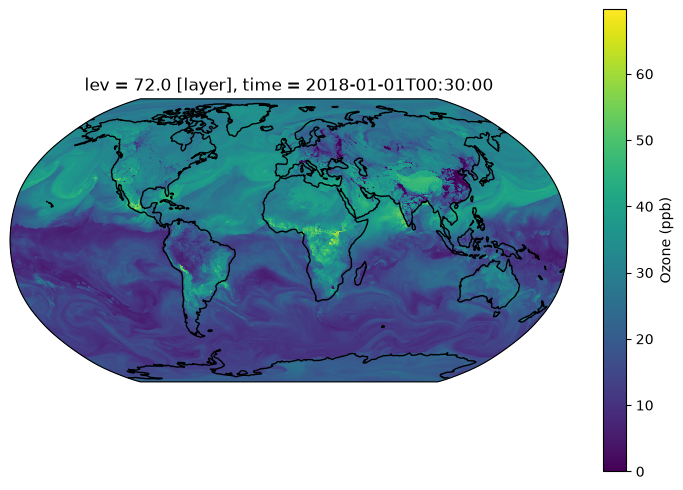

In [24]:
# plot map of ozone in ppb

O3 = ds.O3
O3_ppb = O3*1e9

fig = plt.figure(figsize=(9,6))
ax = plt.axes(projection=ccrs.Robinson())
O3_ppb.plot(ax=ax, transform=ccrs.PlateCarree(), cbar_kwargs={'label': 'Ozone (ppb)'})
ax.coastlines()

In [27]:
# b. What latitude and longitude is O3 highest?

max_location = ds.where(O3_ppb== O3_ppb.max(), drop=True)
print('Lat: ', max_location.lat.values, 'Lon: ', max_location.lon.values)


Lat:  [34.5] Lon:  [-118.75]


In [52]:
# d. What latitude and longitude is O3 lowest?

min_points = O3_ppb.where(O3_ppb == O3_ppb.min(), drop=True)

stacked_points = min_points.stack(points=('lat', 'lon'))
valid = stacked_points.dropna('points')

for lat, lon in valid.points.values:
    print('Lat:', lat, 'Lon:', lon)

# bunch of lat/lon pairs with lowest concentrations

Lat: 53.0 Lon: 73.25
Lat: 53.0 Lon: 73.5
Lat: 53.25 Lon: 73.5
Lat: 53.25 Lon: 73.75
Lat: 55.75 Lon: 38.5
Lat: 55.75 Lon: 39.0
Lat: 55.75 Lon: 39.25
Lat: 55.75 Lon: 39.5
Lat: 56.0 Lon: 38.75
Lat: 56.0 Lon: 39.0
Lat: 56.0 Lon: 39.25
Lat: 56.0 Lon: 39.5


In [33]:
# e. What is the O3 concentration over LA?
O3_ppb.sel(lat=[34.052235], lon=[-118.243683], method="nearest")

<xarray.DataArray 'O3' (time: 1, lev: 1, lat: 1, lon: 1)> Size: 4B
array([[[[45.401974]]]], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 8B 2018-01-01T00:30:00
  * lev      (lev) float64 8B 72.0
  * lat      (lat) float64 8B 34.0
  * lon      (lon) float64 8B -118.2
Attributes:
    long_name:       Ozone (O3, MW = 48.00 g mol-1) volume mixing ratio dry air
    units:           mol mol-1
    fmissing_value:  1e+15
    standard_name:   Ozone (O3, MW = 48.00 g mol-1) volume mixing ratio dry air
    vmin:            -1e+15
    vmax:            1e+15
    valid_range:     [-1.e+15  1.e+15]

In [34]:
# f. What is the O3 concentration over Hawaii?
O3_ppb.sel(lat=[19.741755], lon=[-155.844437], method="nearest")


<xarray.DataArray 'O3' (time: 1, lev: 1, lat: 1, lon: 1)> Size: 4B
array([[[[37.252903]]]], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 8B 2018-01-01T00:30:00
  * lev      (lev) float64 8B 72.0
  * lat      (lat) float64 8B 19.75
  * lon      (lon) float64 8B -155.8
Attributes:
    long_name:       Ozone (O3, MW = 48.00 g mol-1) volume mixing ratio dry air
    units:           mol mol-1
    fmissing_value:  1e+15
    standard_name:   Ozone (O3, MW = 48.00 g mol-1) volume mixing ratio dry air
    vmin:            -1e+15
    vmax:            1e+15
    valid_range:     [-1.e+15  1.e+15]

Final project pitch: 

i. I have buoy data 3 buoys in long beach area, and the data goes back up to 10 years. I got the data from the nation data buoy center. They also have Anemometer data that I could maybe incorporate into this dataset. 
ii. I am interested in doing both regression work and understanding. I want to see if any of the wave energy parameters correspond to benthic fluxes (I have only 3 years worth of benthic data), and if regression could help with that. Or incorporating the air data, see if we can predict wave energy from the nearby anemometers. 
iii. This could be scientifically important with climate change scenarios that mention how winds may increase under CC, and if wind impacts wave energy, and wave energy impacts, benthic flux, there could be some correlation. I know benthic fluxes are driven by many other things other then waves, but I want to focus on waves just to practice machine learning/coding in python, and see if I get any cool results. 
